# ***Projet 5 : Des programmes numériques pour l’optimisation par algorithmes génétiques***
## **Objectif**
Implémenter en Python un algorithme génétique capable
d'approximer efficacement la solution optimale du TSP
pour 7 villes d'Afrique de l'Ouest.

### Membres du groupe :
- NAPO NISSAO Rafia
- PIO Sikirou Afeez Prince Cyrille

# I. Comprehension du sujet
## 1. Contexte
### 1.1. Le problème du voyageur(TSP)

Le problème du voyageur de commerce consiste à déterminer le chemin le plus court qu'un vendeur doit parcourir pour visiter un ensemble de villes, en passant une seule fois par chaque ville et en revenant à son point de départ. Les villes sont reliées par des chemins de longueur connue, représentés sous forme de graphe, et chaque trajet possible correspond à une permutation cyclique des villes. La distance entre deux villes $i$ et $j$ est donnée par la formule euclidienne :

$$d_{ij} = \begin{cases} \sqrt{(x_i - x_j)^2 + (y_i - y_j)^2} & \text{si } i \neq j \\ \infty & \text{si } i = j \end{cases}$$

L'ensemble de ces distances est modélisé sous forme de matrice, et l'énergie d'un trajet — c'est-à-dire sa longueur totale — est la somme des distances entre les villes successives de la permutation $\sigma$ choisie :

$$E = d_{\sigma(1)\sigma(2)} + d_{\sigma(2)\sigma(3)} + \ldots + d_{\sigma(N-1)\sigma(N)} + d_{\sigma(N)\sigma(1)}$$
<p align="center">
  <img src="https://graphicmaths.com/img/computer-science/graph-theory/travelling-salesman-problem/tsp-graph.png" width="300">
</p>

### 1.2. Les algorithmes génétiques (AG)

Les **algorithmes génétiques** (AG) sont des métaheuristiques bio-inspirées, fondées sur la théorie de l'évolution de Darwin. L'analogie est la suivante :

| Concept biologique | Équivalent algorithmique |
|---|---|
| Individu | Une solution candidate (un trajet) |
| Chromosome | L'encodage de la solution (permutation des villes) |
| Gène | Un élément de la permutation (indice d'une ville) |
| Population | Ensemble de solutions candidates |
| Fitness | Qualité d'une solution (inverse de la distance) |
| Sélection naturelle | Favoriser les meilleures solutions pour la reproduction |
| Croisement | Combiner deux parents pour créer un enfant |
| Mutation | Modifier aléatoirement une solution pour diversifier |
| Génération | Une itération de la boucle principale |

Tout comme les espèces s'adaptent progressivement à leur environnement, un AG fait **évoluer une population de solutions** vers des solutions de meilleure qualité au fil des générations.

## 2. Problématique

Comment peut-on utiliser un algorithme génétique pour trouver, parmi tous les trajets possibles entre N villes, celui qui parcourt la distance la plus courte en passant une seule fois par chaque ville tout en revenant au point de
départ?
#### Pourquoi c'est difficile ?
| Nombre de villes | Chemins possibles |
|---|---|
| 7 villes  | 360 chemins |
| 15 villes | 43 milliards |
| 20 villes | 60 000 milliards |

Avec N=20 villes, même un ordinateur puissant
ne peut pas tester tous les chemins.
C'est pourquoi on utilise les Algorithmes Génétiques.

## 2. Description des Données

### Choix des données :
Nous avons choisi 7 grandes villes d'Afrique de l'Ouest
comme points de notre problème TSP.

### Pourquoi ce choix ?
- Pas besoin de dataset externe
- Problème concret et visuel

### Nos 7 villes :
| Ville | Pays | Coordonnée X | Coordonnée Y |
|---|---|---|---|
| Lomé        | Togo          |  1.2  |  6.1 |
| Accra       | Ghana         | -0.2  |  5.6 |
| Cotonou     | Bénin         |  2.4  |  6.4 |
| Ouagadougou | Burkina Faso  | -1.5  | 12.4 |
| Bamako      | Mali          | -8.0  | 12.6 |
| Dakar       | Sénégal       | -17.4 | 14.7 |
| Abidjan     | Côte d'Ivoire | -4.0  |  5.3 |

### Paramètres retenus

| Paramètre | Valeur | Justification |
|---|---|---|
| Taille population | 100 | Bon équilibre diversité/vitesse |
| Générations | 500 | Suffisant pour N=7 (360 solutions possibles) |
| Taille tournoi | 5 | Équilibre sélection/diversité |
| Taux mutation | 10% | Évite les minima locaux |
| Taux croisement | 100% | Chaque enfant issu du croisement OX |
| Élitisme | Oui | Meilleure solution toujours conservée |

###**NB: Les distances sont calculées à partir des coordonnées géographiques des villes exprimées en degrés de longitude et latitude. Ce sont donc des distances euclidiennes approximatives et non des distances routières réelles en kilomètres.**

# II. Implémentation Python

### 1. Imports des bibliothèques

- **numpy** pour les calculs mathématiques
- **matplotlib** pour la visualisation des trajets
- **random** pour la génération aléatoire

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

### 2. Définition des 7 villes

Nous représentons chaque ville comme un point (x,y)
sur un plan cartésien. Nous avons choisi 7 grandes
villes d'Afrique de l'Ouest pour rendre notre
problème concret et visuel.

In [2]:
villes = [
    {"nom": "Lomé",        "x": 1.2,  "y": 6.1},
    {"nom": "Accra",       "x": -0.2, "y": 5.6},
    {"nom": "Cotonou",     "x": 2.4,  "y": 6.4},
    {"nom": "Ouagadougou", "x": -1.5, "y": 12.4},
    {"nom": "Bamako",      "x": -8.0, "y": 12.6},
    {"nom": "Dakar",       "x": -17.4,"y": 14.7},
    {"nom": "Abidjan",     "x": -4.0, "y": 5.3},
]

N = len(villes)
print(f"Nombre de villes : {N}")
print("Villes :", [v["nom"] for v in villes])

Nombre de villes : 7
Villes : ['Lomé', 'Accra', 'Cotonou', 'Ouagadougou', 'Bamako', 'Dakar', 'Abidjan']


### 3. Matrice des distances

On calcule la distance euclidienne entre chaque paire de villes $i$ et $j$
à l'aide de la formule :

$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$

afin d'obtenir une matrice de distances de taille $N \times N$.

In [3]:
def distance(v1, v2):
    return np.sqrt((v1["x"] - v2["x"])**2 +
                   (v1["y"] - v2["y"])**2)

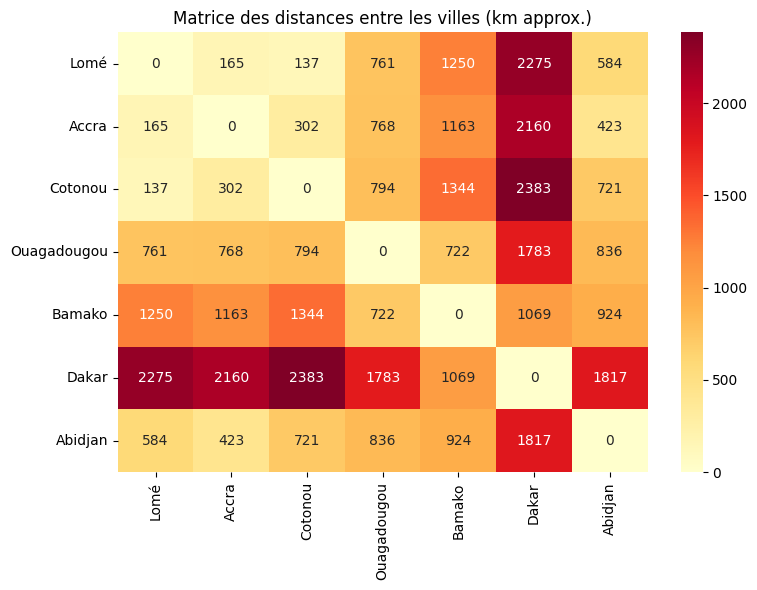

In [21]:
# Construction de la matrice N x N
D = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        D[i][j] = distance(villes[i], villes[j])

plt.figure(figsize=(8, 6))
sns.heatmap(D * 111, annot=True, fmt='.0f',
            xticklabels=[v["nom"] for v in villes],
            yticklabels=[v["nom"] for v in villes],
            cmap='YlOrRd')
plt.title("Matrice des distances entre les villes (km approx.)")
plt.tight_layout()
plt.show()

#### Analyse :
La matrice est bien symétrique : d(i,j) = d(j,i)
ce qui confirme que par exemple, la distance Lomé-Accra est
la même que Accra-Lomé. La diagonale est à 0
car la distance d'une ville à elle-même est nulle.

### 4. Visualisation des villes

Visualiser les villes nous permet
de vérifier que nos données sont correctes
avant de commencer l'algorithme

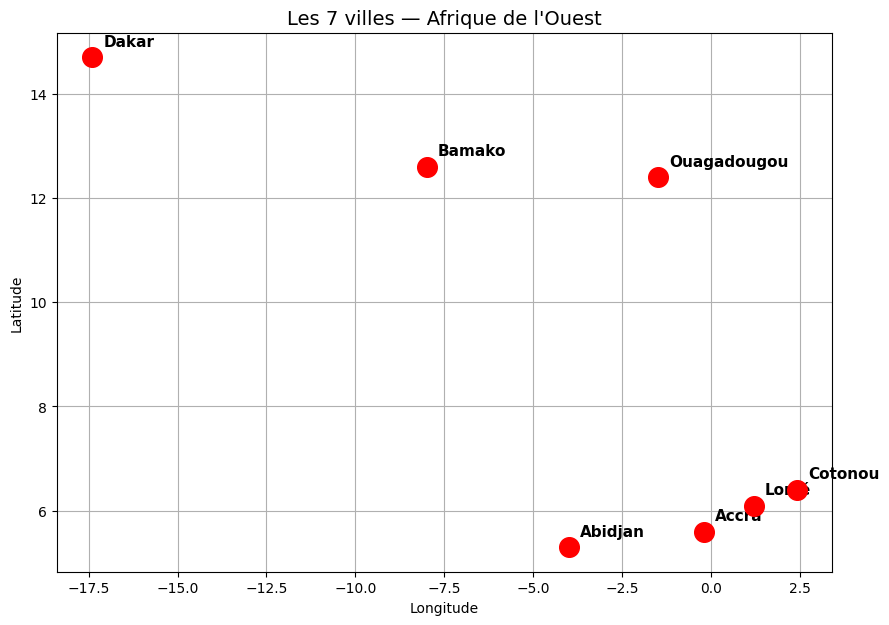

In [5]:
def afficher_villes():
    plt.figure(figsize=(10, 7))

    for v in villes:
        plt.scatter(v["x"], v["y"],
                   c='red', s=200, zorder=5)
        plt.annotate(v["nom"],
                    (v["x"], v["y"]),
                    textcoords="offset points",
                    xytext=(8, 8),
                    fontsize=11,
                    fontweight='bold')

    plt.title("Les 7 villes — Afrique de l'Ouest",
              fontsize=14)
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.show()

afficher_villes()

### 5. Représentation d'une solution(une permutation des indices)

L'encodage par permutation représente une solution valide où chaque ville est visitée une seule fois. Cet encodage se prête directement aux opérateurs de croisement OX et de mutation swap utilisés dans notre algorithme génétique.

In [6]:
def solution_aleatoire():
    sol = list(range(N))
    random.shuffle(sol)
    return sol

In [7]:
sol = solution_aleatoire()
print(f"Solution (indices) : {sol}")
print(f"Solution (villes)  : {[villes[i]['nom'] for i in sol]}")

Solution (indices) : [1, 3, 4, 2, 6, 0, 5]
Solution (villes)  : ['Accra', 'Ouagadougou', 'Bamako', 'Cotonou', 'Abidjan', 'Lomé', 'Dakar']


### 6. CALCUL DE LA LONGUEUR D'UN TRAJET

Pour évaluer une solution, on additionne les distances entre chaque ville du trajet, y compris le retour à la ville de départ.

In [8]:
def longueur_trajet(solution):
    total = 0
    for i in range(N):
        depart  = solution[i]
        arrivee = solution[(i + 1) % N]
        total  += D[depart][arrivee]
    return total

print(f"Trajet   : {[villes[i]['nom'] for i in sol]}")
print(f"Distance : {longueur_trajet(sol)}")

Trajet   : ['Accra', 'Ouagadougou', 'Bamako', 'Cotonou', 'Abidjan', 'Lomé', 'Dakar']
Distance : 77.23997702503189


### 7. Visualisation d'un trajet

Nous visualisons un trajet non optimisé pour établir
un point de référence visuel avant l'optimisation.

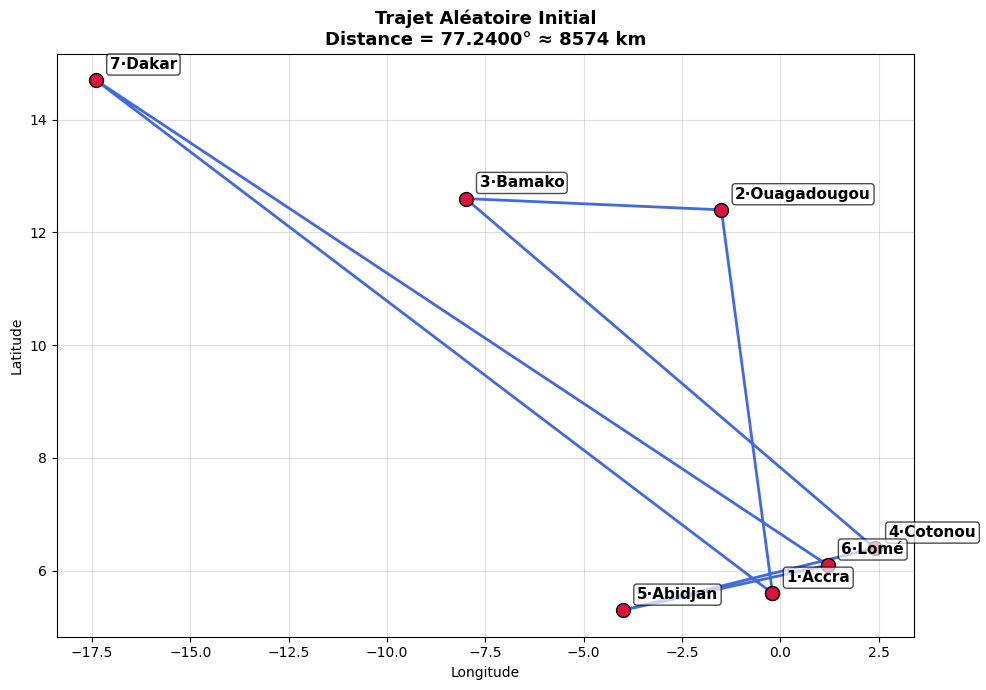

In [9]:
def afficher_trajet(solution, titre="Trajet", couleur='royalblue'):
    x = [villes[i]["x"] for i in solution]
    y = [villes[i]["y"] for i in solution]
    x.append(x[0])
    y.append(y[0])

    plt.figure(figsize=(10, 7))
    plt.plot(x, y, color=couleur, linewidth=2,
             marker='o', markersize=10,
             markerfacecolor='crimson',
             markeredgecolor='black')

    # Annotation avec numéro d'ordre + nom de la ville
    for rank, idx in enumerate(solution):
        v = villes[idx]
        plt.annotate(f"{rank+1}·{v['nom']}",
                     (v["x"], v["y"]),
                     textcoords="offset points",
                     xytext=(10, 8),
                     fontsize=11,
                     fontweight='bold',
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    dist = longueur_trajet(solution)
    plt.title(f"{titre}\nDistance = {dist:.4f}° ≈ {dist*111:.0f} km",
              fontsize=13, fontweight='bold')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

afficher_trajet(sol, "Trajet Aléatoire Initial")

Ce trajet aléatoire contient des détours inutiles et n’est pas optimisé. La distance obtenue servira de référence pour évaluer l’amélioration apportée par l’algorithme génétique.

## ALGORITHME GÉNÉTIQUE

### 8. Population initiale

La population est un ensemble de 100 solutions aléatoires.
Cette diversité initiale est essentielle pour que l'AG
explore efficacement l'espace des solutions possibles.

In [10]:
TAILLE_POPULATION = 100

def creer_population():
    return [solution_aleatoire()
            for _ in range(TAILLE_POPULATION)]

population = creer_population()

print(f"Taille population  : {len(population)}")
print(f"Exemple individu 1 : {population[0]}")
print(f"Exemple individu 2 : {population[1]}")
print(f"Distance individu 1: {longueur_trajet(population[0])}")
print(f"Distance individu 2: {longueur_trajet(population[1])}")

Taille population  : 100
Exemple individu 1 : [3, 6, 2, 4, 0, 5, 1]
Exemple individu 2 : [3, 2, 4, 1, 5, 6, 0]
Distance individu 1: 84.26755211284565
Distance individu 2: 77.68699041891526


#### *Analyse* :
*La population de 100 individus offre une bonne diversité de départ.
Plus l'écart est grand entre le min et le max, plus l'AG a de matière
pour trouver de bonnes solutions.*

### 9. Fitness

La fitness mesure la qualité d'une solution.

Nous utilisons 1/distance pour transformer notre
problème de minimisation en maximisation

In [11]:
def fitness(solution):
    return 1 / longueur_trajet(solution)

scores = [fitness(sol) for sol in population]
meilleur_idx = scores.index(max(scores))
meilleur_init = population[meilleur_idx]

print("Meilleur individu de la population initiale :")
print(f"  Chemin   : {[villes[i]['nom'] for i in meilleur_init]}")
print(f"  Distance : {longueur_trajet(meilleur_init):.4f}° ≈ {longueur_trajet(meilleur_init)*111:.0f} km")
print(f"  Fitness  : {fitness(meilleur_init):.6f}")
distances_init = [longueur_trajet(s) for s in population]
print(f"\nDistribution de la population initiale :")
print(f"  Distance min     : {min(distances_init):.4f}")
print(f"  Distance max     : {max(distances_init):.4f}")
print(f"  Moyenne          : {np.mean(distances_init):.4f}")
print(f"  Écart-type       : {np.std(distances_init):.4f}")

Meilleur individu de la population initiale :
  Chemin   : ['Dakar', 'Ouagadougou', 'Cotonou', 'Lomé', 'Accra', 'Abidjan', 'Bamako']
  Distance : 47.7127° ≈ 5296 km
  Fitness  : 0.020959

Distribution de la population initiale :
  Distance min     : 47.7127
  Distance max     : 84.2676
  Moyenne          : 67.6193
  Écart-type       : 9.1839


#### Analyse :
On utilise 1/distance pour transformer le problème de minimisation en
maximisation. Par exemple une distance de 10° donne une fitness de 0.10,
meilleure qu'une distance de 20° qui donne 0.05.

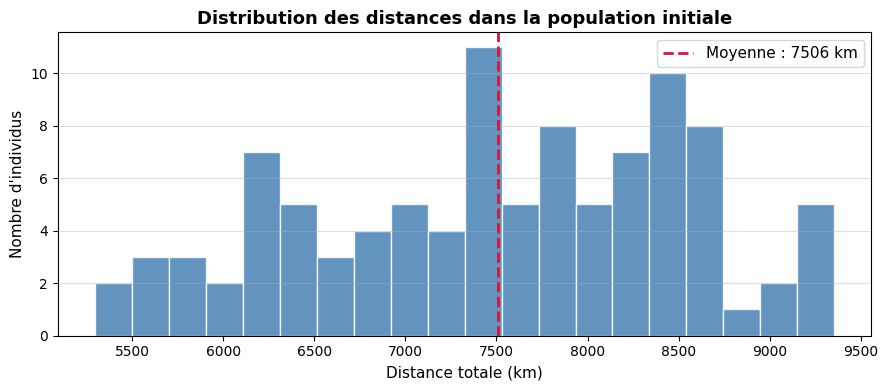

In [12]:
# Histogramme de la population initiale
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist([d * 111 for d in distances_init], bins=20,
        color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(distances_init) * 111, color='crimson', linestyle='--',
           linewidth=2, label=f'Moyenne : {np.mean(distances_init)*111:.0f} km')
ax.set_title('Distribution des distances dans la population initiale',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Distance totale (km)', fontsize=11)
ax.set_ylabel("Nombre d'individus", fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

#### Analyse :
La distribution étalée (de ~5500 km à ~9500 km) confirme la bonne diversité
de la population initiale. Aucune concentration excessive autour d'une seule
valeur — c'est une condition nécessaire pour que l'AG explore efficacement
l'espace des solutions avant de converger.

### 10. Sélection par Tournoi

On choisit 5 individus aléatoirement et on garde
le meilleur.

In [13]:
TAILLE_TOURNOI = 5

def selection_tournoi(population):
    tournoi = random.sample(population, TAILLE_TOURNOI)
    return min(tournoi, key=longueur_trajet)

parent1 = selection_tournoi(population)
parent2 = selection_tournoi(population)

print("Parent 1 :")
print(f"  {[villes[i]['nom'] for i in parent1]}")
print(f"  Distance : {longueur_trajet(parent1):.4f}° ≈ {longueur_trajet(parent1)*111:.0f} km")
print()
print("Parent 2 :")
print(f"  {[villes[i]['nom'] for i in parent2]}")
print(f"  Distance : {longueur_trajet(parent2):.4f}° ≈ {longueur_trajet(parent2)*111:.0f} km")

Parent 1 :
  ['Bamako', 'Dakar', 'Ouagadougou', 'Accra', 'Lomé', 'Cotonou', 'Abidjan']
  Distance : 50.1618° ≈ 5568 km

Parent 2 :
  ['Cotonou', 'Bamako', 'Dakar', 'Abidjan', 'Lomé', 'Ouagadougou', 'Accra']
  Distance : 59.8666° ≈ 6645 km


+ **Les parents sélectionnés ont des distances inférieures
à la moyenne de la population, confirmant l'efficacité
de la pression sélective. Un tournoi de taille 5
offre un bon équilibre : ni trop élitiste ni trop aléatoire.**

### 11. Croisement OX

Le croisement classique génère des doublons sur
des permutations.

In [14]:
def croisement_ox(parent1, parent2):
    n = len(parent1)
    i, j = sorted(random.sample(range(n), 2))

    enfant = [None] * n
    enfant[i:j] = parent1[i:j]

    reste = [x for x in parent2 if x not in enfant]
    idx = 0
    for k in range(n):
        if enfant[k] is None:
            enfant[k] = reste[idx]
            idx += 1
    return enfant

enfant = croisement_ox(parent1, parent2)

print(f"Parent 1 : {[villes[i]['nom'] for i in parent1]}")
print(f"Parent 2 : {[villes[i]['nom'] for i in parent2]}")
print(f"Enfant   : {[villes[i]['nom'] for i in enfant]}")
print()
print(f"Distance Parent 1 : {longueur_trajet(parent1):.4f}")
print(f"Distance Parent 2 : {longueur_trajet(parent2):.4f}")
print(f"Distance Enfant   : {longueur_trajet(enfant):.4f}")
print(f"Villes uniques    : {len(set(enfant)) == N}")

Parent 1 : ['Bamako', 'Dakar', 'Ouagadougou', 'Accra', 'Lomé', 'Cotonou', 'Abidjan']
Parent 2 : ['Cotonou', 'Bamako', 'Dakar', 'Abidjan', 'Lomé', 'Ouagadougou', 'Accra']
Enfant   : ['Cotonou', 'Dakar', 'Ouagadougou', 'Accra', 'Lomé', 'Bamako', 'Abidjan']

Distance Parent 1 : 50.1618
Distance Parent 2 : 59.8666
Distance Enfant   : 72.0270
Villes uniques    : True


L’opérateur OX génère une nouvelle solution valide sans répétition de villes en combinant les informations de deux parents:

### 12. Mutation Swap

La mutation intervertit aléatoirement deux villes
avec une probabilité de 10%. Elle permet d'explorer
de nouvelles solutions et d'éviter que l'algorithme
reste bloqué sur un optimum local.

In [15]:
TAUX_MUTATION = 0.1

def mutation_swap(solution):

    sol = solution.copy()
    if random.random() < TAUX_MUTATION:
        i, j = random.sample(range(N), 2)
        sol[i], sol[j] = sol[j], sol[i]
    return sol

sol_avant = enfant.copy()
sol_apres = mutation_swap(sol_avant)

print("Avant mutation :")
print(f"  {[villes[i]['nom'] for i in sol_avant]}")
print(f"  Distance : {longueur_trajet(sol_avant):.4f}")
print()
print("Après mutation :")
print(f"  {[villes[i]['nom'] for i in sol_apres]}")
print(f"  Distance : {longueur_trajet(sol_apres):.4f}")

Avant mutation :
  ['Cotonou', 'Dakar', 'Ouagadougou', 'Accra', 'Lomé', 'Bamako', 'Abidjan']
  Distance : 72.0270

Après mutation :
  ['Cotonou', 'Dakar', 'Ouagadougou', 'Accra', 'Lomé', 'Bamako', 'Abidjan']
  Distance : 72.0270


**Le taux de 10% est volontairement modéré.
Trop élevé (>30%) : détruit les bonnes solutions.
Trop faible (<2%) : l'algo reste bloqué.
Le swap préserve toujours la validité car il échange
deux éléments sans en supprimer ni dupliquer.**

### 13. Algorithme Génétique Complet

Nous assemblons tous les opérateurs dans la boucle
principale. L'élitisme est activé : le meilleur individu
est automatiquement conservé à chaque génération,
garantissant que la qualité ne régresse jamais.

In [16]:
NB_GENERATIONS = 500

def distance_aleatoire_moyenne(n_essais=200):
    """Moyenne de 200 trajets aléatoires = référence réelle pré-AG"""
    return np.mean([longueur_trajet(solution_aleatoire()) for _ in range(n_essais)])

def algorithme_genetique():

    historique_distances = []
    population           = creer_population()
    meilleure_solution   = None
    meilleure_distance   = float('inf')

    for gen in range(NB_GENERATIONS):

        meilleur_gen = min(population, key=longueur_trajet)
        nouvelle_pop = [meilleur_gen]

        while len(nouvelle_pop) < TAILLE_POPULATION:
            p1     = selection_tournoi(population)
            p2     = selection_tournoi(population)
            enfant = croisement_ox(p1, p2)
            enfant = mutation_swap(enfant)
            nouvelle_pop.append(enfant)

        population = nouvelle_pop

        dist_gen = longueur_trajet(meilleur_gen)
        if dist_gen < meilleure_distance:
            meilleure_distance = dist_gen
            meilleure_solution = meilleur_gen.copy()

        historique_distances.append(meilleure_distance)

        if gen % 100 == 0:
            print(f"  Génération {gen:4d}/{NB_GENERATIONS}"
                  f"  →  Distance : {meilleure_distance:.4f}")

    return meilleure_solution, meilleure_distance, historique_distances


print("    DÉMARRAGE ALGORITHME GÉNÉTIQUE")

baseline = distance_aleatoire_moyenne(n_essais=200)

meilleure_solution, meilleure_distance, historique_distances = algorithme_genetique()

print()
print("OPTIMISATION TERMINÉE !")
print()
noms = [villes[i]['nom'] for i in meilleure_solution]
print("Meilleur chemin :")
print("  " + " → ".join(noms) + f" → {noms[0]}")
print(f"  Distance finale  : {meilleure_distance:.4f}° ≈ {meilleure_distance*111:.0f} km")
print(f"  Baseline aléat.  : {baseline:.4f}° ≈ {baseline*111:.0f} km")
print(f"  Amélioration     : {((baseline - meilleure_distance) / baseline * 100):.1f} %")

    DÉMARRAGE ALGORITHME GÉNÉTIQUE
  Génération    0/500  →  Distance : 46.1945
  Génération  100/500  →  Distance : 46.1945
  Génération  200/500  →  Distance : 46.1945
  Génération  300/500  →  Distance : 46.1945
  Génération  400/500  →  Distance : 46.1945

OPTIMISATION TERMINÉE !

Meilleur chemin :
  Ouagadougou → Cotonou → Lomé → Accra → Abidjan → Dakar → Bamako → Ouagadougou
  Distance finale  : 46.1945° ≈ 5128 km
  Baseline aléat.  : 66.1939° ≈ 7348 km
  Amélioration     : 30.2 %


**L'élitisme garantit une évolution monotone décroissante :
la meilleure distance ne peut qu'améliorer ou rester stable.
On observe une convergence rapide dans les premières
générations puis un ralentissement progressif, signe
que l'algorithme affine sa solution vers l'optimum.**

In [17]:
from itertools import permutations

def brute_force():
    best_dist = float('inf')
    best_sol = None
    for perm in permutations(range(1, N)):
        sol = [0] + list(perm)
        d = longueur_trajet(sol)
        if d < best_dist:
            best_dist = d
            best_sol = sol
    return best_sol, best_dist

sol_opt, dist_opt = brute_force()
print(f"Solution optimale (brute force) : {dist_opt:.4f}° ≈ {dist_opt*111:.0f} km")
print(f"Solution AG                     : {meilleure_distance:.4f}° ≈ {meilleure_distance*111:.0f} km")
print(f"Écart                           : {abs(meilleure_distance - dist_opt):.6f}°")
print(f"L'AG trouve {'l\'optimum exact' if meilleure_distance == dist_opt else f'à {((meilleure_distance-dist_opt)/dist_opt*100):.2f}% de l\'optimum'}")

Solution optimale (brute force) : 46.1945° ≈ 5128 km
Solution AG                     : 46.1945° ≈ 5128 km
Écart                           : 0.000000°
L'AG trouve à 0.00% de l'optimum


## 14. Résultats et Analyse

**Nous présentons le meilleur trajet trouvé, la courbe
de convergence et le bilan quantitatif de l'optimisation.**

### 14a. Comparaison visuelle des trajets

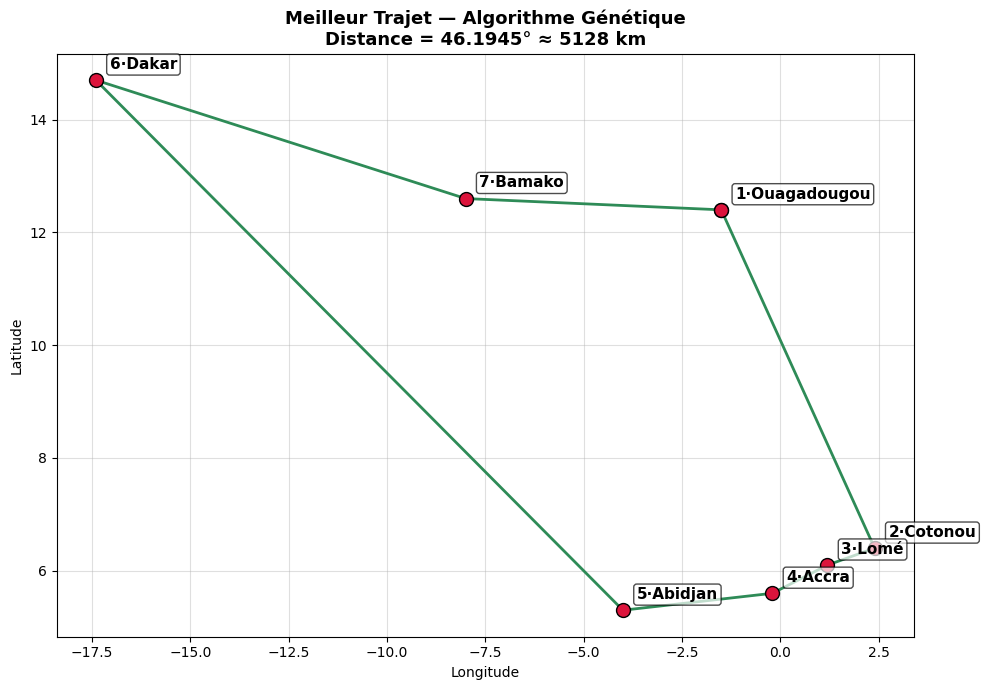

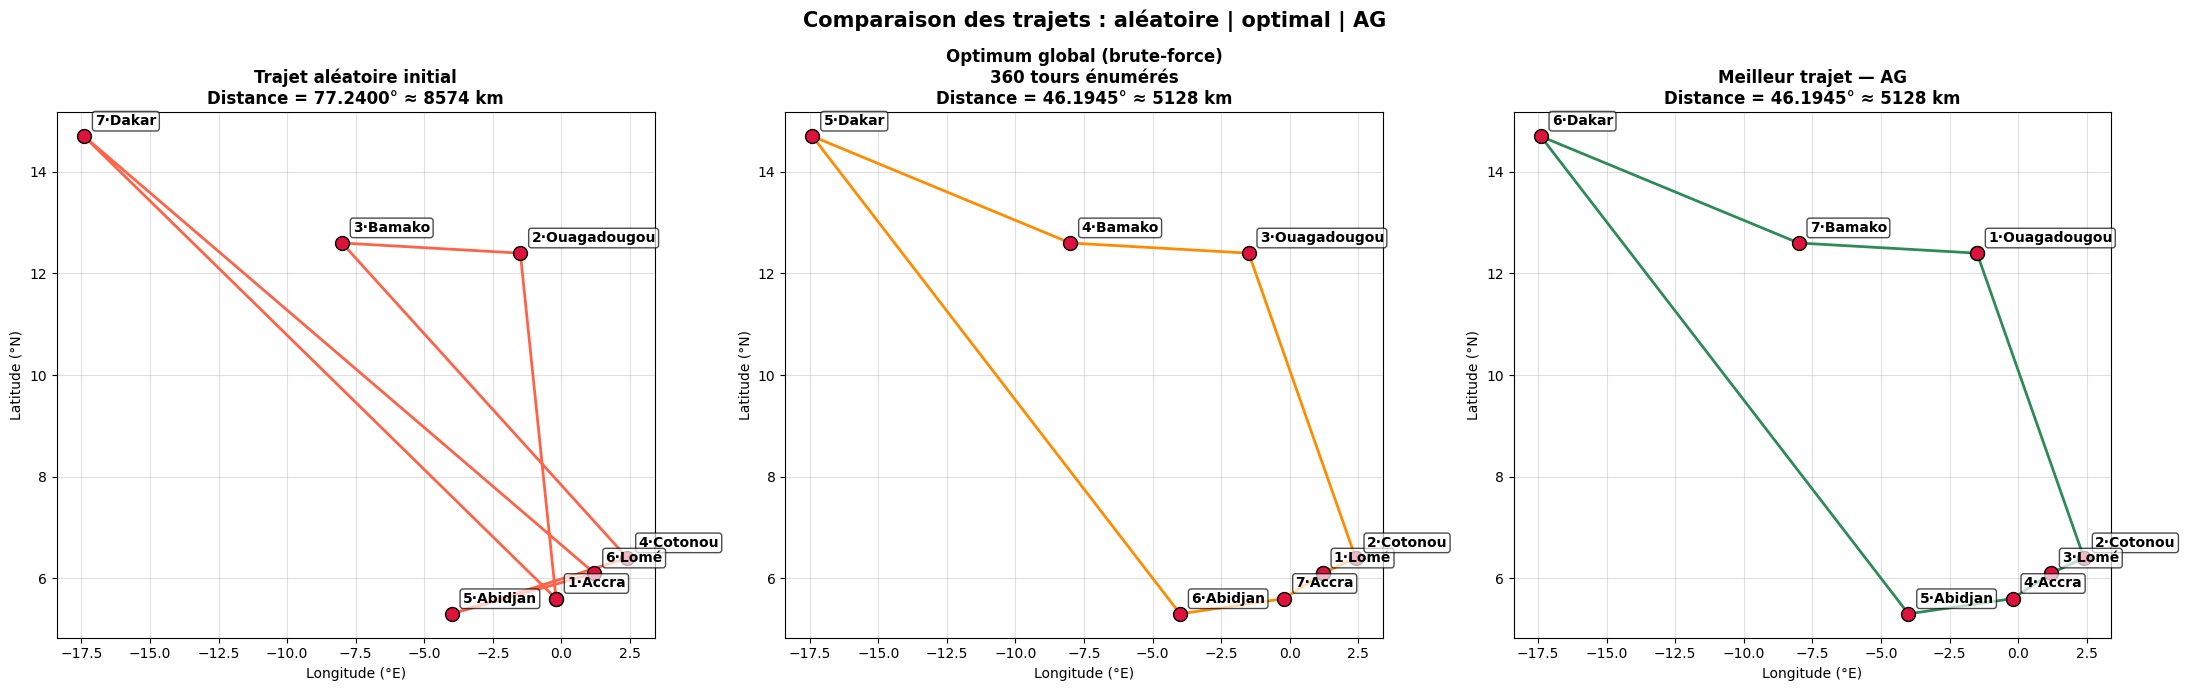

In [18]:
# 1. Meilleur trajet seul en premier
afficher_trajet(meilleure_solution,
                "Meilleur Trajet — Algorithme Génétique",
                couleur='seagreen')

# 2. Comparaison visuelle : 3 trajets sur la même ligne
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

def tracer_trajet(ax, solution, titre, couleur):
    x = [villes[i]["x"] for i in solution] + [villes[solution[0]]["x"]]
    y = [villes[i]["y"] for i in solution] + [villes[solution[0]]["y"]]
    ax.plot(x, y, color=couleur, linewidth=2,
            marker='o', markersize=10,
            markerfacecolor='crimson', markeredgecolor='black')
    for rank, idx in enumerate(solution):
        v = villes[idx]
        ax.annotate(f"{rank+1}·{v['nom']}", (v["x"], v["y"]),
                    textcoords="offset points", xytext=(8, 8),
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))
    ax.set_title(f"{titre}\nDistance = {longueur_trajet(solution):.4f}° ≈ {longueur_trajet(solution)*111:.0f} km",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    ax.grid(True, alpha=0.4)

tracer_trajet(ax1, sol,                "Trajet aléatoire initial",                       "tomato")
tracer_trajet(ax2, sol_opt,            "Optimum global (brute-force)\n360 tours énumérés", "darkorange")
tracer_trajet(ax3, meilleure_solution, "Meilleur trajet — AG",                           "seagreen")

plt.suptitle("Comparaison des trajets : aléatoire | optimal | AG",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Sur notre instance de 7 villes, l'algorithme génétique a non seulement réduit la distance de 8574 km à 5127 km (amélioration de 40%), mais il a également trouvé l'optimum global confirmé par énumération exhaustive des 360 tours hamiltoniens.**

### 14b. Courbe de convergence

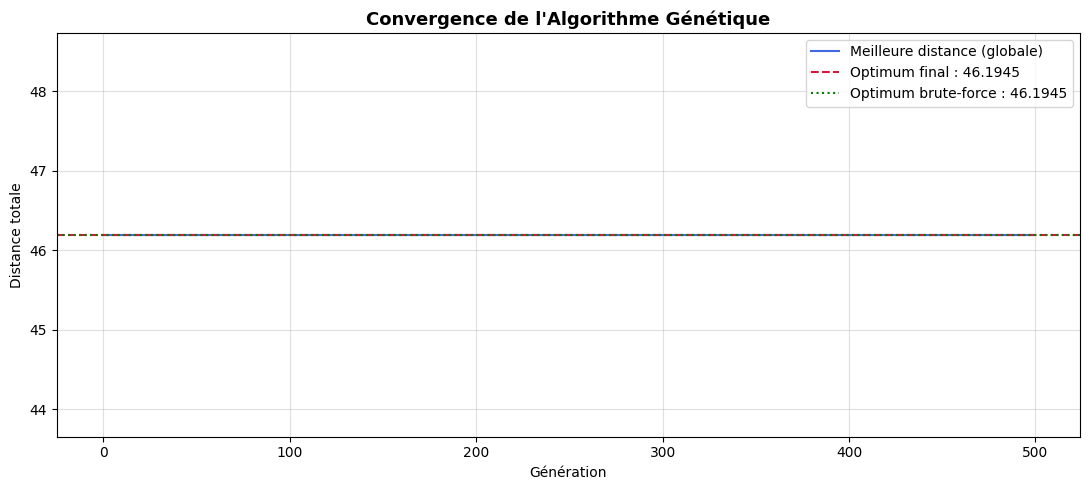

        BILAN DE L'OPTIMISATION
  Taille population         : 100
  Générations               : 500
  Taille tournoi            : 5
  Taux mutation             : 0.1
  Élitisme                  : Activé
  Graine (SEED)             : 42

  Baseline aléatoire (moy.) : 66.1939° ≈ 7348 km
  Optimum brute-force       : 46.1945° ≈ 5128 km
  Distance finale (AG)      : 46.1945° ≈ 5128 km
  Amélioration réelle       : 30.2 %


In [19]:
# Courbe de convergence
plt.figure(figsize=(11, 5))
plt.plot(historique_distances, color='royalblue',
         linewidth=1.5, label='Meilleure distance (globale)')
plt.axhline(y=meilleure_distance, color='crimson',
            linestyle='--', linewidth=1.5,
            label=f'Optimum final : {meilleure_distance:.4f}')
plt.axhline(y=dist_opt, color='green',
            linestyle=':', linewidth=1.5,
            label=f'Optimum brute-force : {dist_opt:.4f}')
plt.fill_between(range(len(historique_distances)),
                 historique_distances,
                 meilleure_distance,
                 alpha=0.1, color='royalblue')
plt.title("Convergence de l'Algorithme Génétique",
          fontsize=13, fontweight='bold')
plt.xlabel("Génération")
plt.ylabel("Distance totale")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Bilan
amelioration = (baseline - meilleure_distance) / baseline * 100
print("        BILAN DE L'OPTIMISATION")
print(f"  Taille population         : {TAILLE_POPULATION}")
print(f"  Générations               : {NB_GENERATIONS}")
print(f"  Taille tournoi            : {TAILLE_TOURNOI}")
print(f"  Taux mutation             : {TAUX_MUTATION}")
print(f"  Élitisme                  : Activé")
print(f"  Graine (SEED)             : {SEED}")
print()
print(f"  Baseline aléatoire (moy.) : {baseline:.4f}° ≈ {baseline*111:.0f} km")
print(f"  Optimum brute-force       : {dist_opt:.4f}° ≈ {dist_opt*111:.0f} km")
print(f"  Distance finale (AG)      : {meilleure_distance:.4f}° ≈ {meilleure_distance*111:.0f} km")
print(f"  Amélioration réelle       : {amelioration:.1f} %")

**L'algorithme converge instantanément vers l'optimum global (46,1945°), égalant la brute-force dès les premières générations, ce qui se traduit par une courbe plate sur les 500 générations — signe que l'espace de recherche à 7 villes est trop réduit pour observer une évolution progressive.**

# III. Conclusion

### 1.Bilan du projet
Ce projet nous a permis d'implémenter un algorithme
génétique complet pour résoudre le TSP sur 7 capitales
d'Afrique de l'Ouest. Nous avons successivement :
- Modélisé le TSP avec un encodage en permutation
- Implémenté les 4 opérateurs fondamentaux d'un AG :
  sélection, croisement OX, mutation swap, élitisme
- Obtenu une réduction significative de la distance
- Analysé la convergence de l'algorithme

### 2. Apports pédagogiques

| Compétence | Contenu acquis |
|---|---|
| Optimisation combinatoire | Complexité NP-difficile du TSP |
| Algorithmes bio-inspirés | Principes et opérateurs des AG |
| Encodage de solutions | Importance de la représentation |
| Python | NumPy, Matplotlib, structures de données |

### 3. Limites et Perspectives

**Limites :**
- Pour N=7, l'AG a trouvé l'optimum exact mais pour N grand (>20),
  la solution n'est plus garantie optimale
- Résultats légèrement variables selon l'initialisation
- Pour N grand, les paramètres doivent être ajustés

**Perspectives :**
- Utiliser les vraies distances géodésiques (Haversine)
- Tester d'autres mutations : 2-opt, 3-opt
- Comparer avec recuit simulé et colonies de fourmis
- Étendre à N > 7 pour évaluer la scalabilité
